In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

from IPython.display import display




In [2]:
import yfinance as yf

stock = input("Enter stock symbol (Ex. TCS, RELIANCE, INFY): ").upper()

stock += ".NS"

print("Downloading data.....")

try:
    df = yf.download(stock, period="10y")

    if df.empty:
        print("Please enter a valid stock symbol. Data not found!")
    else:
        print("Download successful!\n")

        
       
        
        

        filename = f"data/{stock}.csv"
        df.to_csv(filename)

        pd.read_csv(filename)

        display(df)

except Exception as e:
    print("An error occurred while downloading data.")
    print("Error:", e)

Enter stock symbol (Ex. TCS, RELIANCE, INFY):  rentomojo


[*********************100%***********************]  1 of 1 completed

Download successful!



Price,Close,High,Low,Open,Volume
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS
Date,,,,,
2026-09-17,534.25,546.799988,482.450012,482.450012,45889291
2026-09-18,534.25,570.000000,570.000000,570.000000,45889328


In [3]:
df.head()

df.tail()


df.shape

df.columns

df.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2 entries, 2026-09-17 to 2026-09-18
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, RENTOMOJO.NS)   2 non-null      float64
 1   (High, RENTOMOJO.NS)    2 non-null      float64
 2   (Low, RENTOMOJO.NS)     2 non-null      float64
 3   (Open, RENTOMOJO.NS)    2 non-null      float64
 4   (Volume, RENTOMOJO.NS)  2 non-null      int64  
dtypes: float64(4), int64(1)
memory usage: 96.0 bytes


In [4]:
df.describe()


Price,Close,High,Low,Open,Volume
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS
count,2.00,2.000000,2.000000,2.000000,2.000000e+00
mean,534.25,558.399994,526.225006,526.225006,4.588931e+07
std,0.00,16.404886,61.907190,61.907190,2.616295e+01
min,534.25,546.799988,482.450012,482.450012,4.588929e+07
25%,534.25,552.599991,504.337509,504.337509,4.588930e+07
50%,534.25,558.399994,526.225006,526.225006,4.588931e+07
75%,534.25,564.199997,548.112503,548.112503,4.588932e+07
max,534.25,570.000000,570.000000,570.000000,4.588933e+07


In [5]:

df.isnull().sum()


Price   Ticker      
Close   RENTOMOJO.NS    0
High    RENTOMOJO.NS    0
Low     RENTOMOJO.NS    0
Open    RENTOMOJO.NS    0
Volume  RENTOMOJO.NS    0
dtype: int64

In [6]:

df.duplicated().sum()

np.int64(0)

In [7]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Convert Date to datetime
df.index = pd.to_datetime(df.index)

# Sort by date
df.sort_index(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2 entries, 2026-09-17 to 2026-09-18
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, RENTOMOJO.NS)   2 non-null      float64
 1   (High, RENTOMOJO.NS)    2 non-null      float64
 2   (Low, RENTOMOJO.NS)     2 non-null      float64
 3   (Open, RENTOMOJO.NS)    2 non-null      float64
 4   (Volume, RENTOMOJO.NS)  2 non-null      int64  
dtypes: float64(4), int64(1)
memory usage: 96.0 bytes


In [9]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


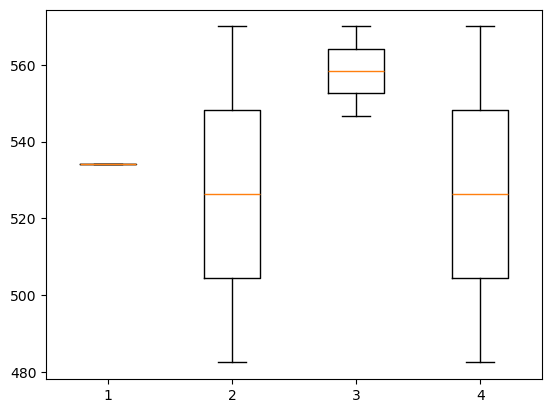

In [10]:
import matplotlib.pyplot as plt

plt.boxplot(df[["Close",'Open','High','Low']])
plt.show()

In [11]:
print(df.head())

Price             Close         High          Low         Open       Volume
Ticker     RENTOMOJO.NS RENTOMOJO.NS RENTOMOJO.NS RENTOMOJO.NS RENTOMOJO.NS
Date                                                                       
2026-09-17       534.25   546.799988   482.450012   482.450012     45889291
2026-09-18       534.25   570.000000   570.000000   570.000000     45889328


# Phase 1: Tomorrow high value 

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np

from IPython.display import display




In [13]:
import yfinance as yf

stock = input("Enter stock symbol (Ex. TCS, RELIANCE, INFY): ").upper()

stock += ".NS"

print("Downloading data.....")

try:
    df = yf.download(stock, period="10y")

    if df.empty:
        print("Please enter a valid stock symbol. Data not found!")
    else:
        print("Download successful!\n")

        
        filename = f"data/{stock}.csv"
        df.to_csv(filename)

        pd.read_csv(filename)

        display(df)

except Exception as e:
    print("An error occurred while downloading data.")
    print("Error:", e)

Enter stock symbol (Ex. TCS, RELIANCE, INFY):  rentomojo


[*********************100%***********************]  1 of 1 completed

Download successful!



Price,Close,High,Low,Open,Volume
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS
Date,,,,,
2026-09-17,534.25,546.799988,482.450012,482.450012,45889291
2026-09-18,534.25,570.000000,570.000000,570.000000,45889328


In [16]:
predict_df = df.copy()

In [17]:
train_df = df.copy()

In [18]:
train_df["Prev_Close"] = train_df["Close"].shift(1)
train_df["Prev_High"] = train_df["High"].shift(1)
train_df["Prev_Low"] = train_df["Low"].shift(1)
train_df["Prev_Volume"] = train_df["Volume"].shift(1)

In [19]:
predict_df["Prev_Close"] = predict_df["Close"].shift(1)
predict_df["Prev_High"] = predict_df["High"].shift(1)
predict_df["Prev_Low"] = predict_df["Low"].shift(1)
predict_df["Prev_Volume"] = predict_df["Volume"].shift(1)

In [20]:
train_df["Tomorrow_High"] = train_df["High"].shift(-1)

In [21]:
train_df

Price,Close,High,Low,Open,Volume,Prev_Close,Prev_High,Prev_Low,Prev_Volume,Tomorrow_High
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,,,,,
Date,,,,,,,,,,
2026-09-17,534.25,546.799988,482.450012,482.450012,45889291,NaN,NaN,NaN,NaN,570.0
2026-09-18,534.25,570.000000,570.000000,570.000000,45889328,534.25,546.799988,482.450012,45889291.0,NaN


In [22]:
train_df.dropna(inplace=True)


In [23]:
df.tail(1)

Price,Close,High,Low,Open,Volume
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS
Date,,,,,
2026-09-18,534.25,570.0,570.0,570.0,45889328


In [24]:
features = [
   "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Prev_Close",
    "Prev_High",
    "Prev_Low",
    "Prev_Volume"
]

In [25]:
X = train_df[features]

y = train_df["Tomorrow_High"]

In [26]:
test_days = int(train_df.shape[0] * 0.2)

X_train = X.iloc[:-test_days]
X_test = X.iloc[-test_days:]

y_train = y.iloc[:-test_days]
y_test = y.iloc[-test_days:]

In [29]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (0, 9)
Test : (0, 9)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

ValueError: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by StandardScaler.

In [32]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train_scaled, y_train)

NameError: name 'X_train_scaled' is not defined

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

prediction = model.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 :", r2_score(y_test, prediction))

NameError: name 'X_test_scaled' is not defined

In [34]:
latest = predict_df[features].tail(2).head(1)

latest_scaled = scaler.transform(latest)

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [35]:
latest

Price,Open,High,Low,Close,Volume,Prev_Close,Prev_High,Prev_Low,Prev_Volume
Ticker,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,RENTOMOJO.NS,,,,
Date,,,,,,,,,
2026-09-17,482.450012,546.799988,482.450012,534.25,45889291,NaN,NaN,NaN,NaN


In [36]:
tomorrow_high = model.predict(latest_scaled)

print("Tomorrow High Prediction")

print(tomorrow_high[0])

NameError: name 'latest_scaled' is not defined

In [37]:
result = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test.values,
    "Predicted": prediction
})

result = result.sort_index(ascending=False)
result

NameError: name 'prediction' is not defined

In [38]:
display_result = result.copy()

display_result["Date"] = display_result["Date"] + pd.Timedelta(days=1)

display_result.sort_values("Date", ascending=False)

NameError: name 'result' is not defined

In [40]:
class ImplementLR:
    
    def __init__(self):
        
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())* (y_train[i] - y_train.mean()))
            
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
    
        self.m = num/den
        self.b =  y_train.mean() - (self.m * X_train.mean())
        
        print("Slop = ",self.m)
        print("Intercept = ",self.b)
        
    
    def predict(self,X_test):
        print(X_test)
        
        return self.m * X_test + self.b
        